In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from matplotlib.lines import Line2D

In [2]:
# ============================================================
# User settings
# ============================================================

flag_save_plot = False
plot_filename = "delta_cdm_monopole_vs_lcdm.pdf"

# Choose a few k-modes to track
# IMPORTANT:
# In CLASS transfer output, k is often returned in h/Mpc.
# We will assume that here and interpolate in those units.
k_modes = np.array([1e-3, 1e-2, 5e-2])   # [h/Mpc]

# Redshift sampling for perturbation history
# Log-spaced to capture both early and late evolution
z_samples = np.unique(np.geomspace(0.0 + 1e-3, 2000.0, 220).astype(float))
z_samples = np.sort(z_samples)[::-1]   # descending: high z -> low z


In [3]:
# ============================================================
# Base cosmology
# ============================================================

base = {
    '100*theta_s': 1.04077,
    'omega_b': 0.02225,
    'omega_cdm': 0.1198,
    'tau_reio': 0.0790,
    'ln10^{10}A_s': 3.094,
    'n_s': 0.9645,

    'output': 'mTk',
    'gauge': 'synchronous',
    'matter_source_in_current_gauge': 'yes',

    'z_max_pk': 2500.0,
    'P_k_max_h/Mpc': 1.0,
}


In [4]:
# ============================================================
# Monopole cases
# ============================================================

cases = [
    # {"label": r"$\kappa=100,\ a_t=1/41,\ \zeta=0.05$", "f_mon": 0.05, "a_t_mon": 1/(40+1), "kappa_mon": 100},
{
    "label": "$\\kappa = 7.3077$\n$ a_t = 1/121$\n$\\zeta = 0.05$",
    "f_mon": 0.05,
    "a_t_mon": 1/(120+1),
    "kappa_mon": 7.3077,
},]


In [5]:
# ============================================================
# Helpers
# ============================================================

def build_model(base_params, extra_params=None):
    """
    Return a fresh Class instance with given parameters loaded and computed.
    """
    cosmo = Class()
    pars = dict(base_params)
    if extra_params is not None:
        pars.update(extra_params)
    cosmo.set(pars)
    cosmo.compute()
    return cosmo


def get_transfer_dict(cosmo, z):
    """
    Wrapper around get_transfer(z), returning the transfer dictionary.
    """
    tr = cosmo.get_transfer(z)
    return tr


def print_transfer_keys_once(cosmo, z=0.0):
    """
    Print available transfer keys to help identify the exact naming in this CLASS fork.
    """
    tr = get_transfer_dict(cosmo, z)
    print(f"\nAvailable transfer keys at z={z}:")
    for key in tr.keys():
        print("   ", repr(key))


def find_key(possible_names, available_keys):
    """
    Return the first matching key from possible_names that exists in available_keys.
    """
    for name in possible_names:
        if name in available_keys:
            return name
    return None


def extract_delta_cdm_from_transfer(tr):
    """
    Extract k-array and CDM density contrast from a transfer dictionary.

    IMPORTANT:
    CLASS/forks may use slightly different key names.
    This function tries several common possibilities.
    """

    keys = list(tr.keys())

    # Common possibilities for k
    k_key = find_key(
        [
            'k (h/Mpc)',
            'k [h/Mpc]',
            'k_hmpc',
            'k',
        ],
        keys
    )

    # Common possibilities for CDM density contrast
    dcdm_key = find_key(
        [
            'd_cdm',
            'delta_cdm',
            'delta_c',
            'd_c',
        ],
        keys
    )

    if k_key is None:
        raise KeyError(
            "Could not find the k-array key in transfer output.\n"
            f"Available keys: {keys}"
        )

    if dcdm_key is None:
        raise KeyError(
            "Could not find the CDM density contrast key in transfer output.\n"
            f"Available keys: {keys}"
        )

    k_arr = np.asarray(tr[k_key], dtype=float)
    d_cdm = np.asarray(tr[dcdm_key], dtype=float)

    return k_arr, d_cdm, k_key, dcdm_key


def compute_delta_history(base_params, z_grid, k_modes_hmpc, extra_params=None, verbose=False):
    """
    Compute delta_cdm(z, k) for chosen k-modes.

    Returns
    -------
    result : dict with keys
        'z'            : redshift grid
        'a'            : scale factor grid
        'k_modes'      : requested k-modes [h/Mpc]
        'delta_cdm'    : array shape (Nz, Nk)
        'k_key'        : actual key used for k in transfer output
        'delta_key'    : actual key used for delta_cdm in transfer output
    """
    cosmo = build_model(base_params, extra_params)

    if verbose:
        print_transfer_keys_once(cosmo, z=z_grid[0])

    delta_hist = np.zeros((len(z_grid), len(k_modes_hmpc)))

    used_k_key = None
    used_delta_key = None

    try:
        for iz, z in enumerate(z_grid):
            tr = get_transfer_dict(cosmo, z)
            k_arr, d_cdm, k_key, d_key = extract_delta_cdm_from_transfer(tr)

            if used_k_key is None:
                used_k_key = k_key
            if used_delta_key is None:
                used_delta_key = d_key

            # Sort if needed before interpolation
            order = np.argsort(k_arr)
            k_sorted = k_arr[order]
            d_sorted = d_cdm[order]

            # Interpolate onto requested k-modes
            delta_hist[iz, :] = np.interp(
                k_modes_hmpc,
                k_sorted,
                d_sorted,
                left=np.nan,
                right=np.nan
            )

    finally:
        cosmo.struct_cleanup()
        cosmo.empty()

    return {
        "z": np.asarray(z_grid, dtype=float),
        "a": 1.0 / (1.0 + np.asarray(z_grid, dtype=float)),
        "k_modes": np.asarray(k_modes_hmpc, dtype=float),
        "delta_cdm": delta_hist,
        "k_key": used_k_key,
        "delta_key": used_delta_key,
    }


In [6]:
# ============================================================
# Run LCDM
# ============================================================

lcdm = compute_delta_history(
    base_params=base,
    z_grid=z_samples,
    k_modes_hmpc=k_modes,
    extra_params=None,
    verbose=True,   # set False after first successful test
)

print("\nDetected transfer keys:")
print("  k key      :", lcdm["k_key"])
print("  delta key  :", lcdm["delta_key"])



Available transfer keys at z=2000.0:
    'k (h/Mpc)'
    'd_g'
    'd_b'
    'd_cdm'
    'd_ur'
    'd_m'
    'd_tot'
    'phi'
    'psi'

Detected transfer keys:
  k key      : k (h/Mpc)
  delta key  : d_cdm


In [7]:
# ============================================================
# Run monopole models
# ============================================================

models = []

for case in cases:
    res = compute_delta_history(
        base_params=base,
        z_grid=z_samples,
        k_modes_hmpc=k_modes,
        extra_params={
            "f_mon": case["f_mon"],
            "a_t_mon": case["a_t_mon"],
            "kappa_mon": case["kappa_mon"],
        },
        verbose=True,
    )
    res["label"] = case["label"]
    res["params"] = dict(case)
    models.append(res)

print("\nDetected transfer keys:")
print("  k key      :", models[0]["k_key"])
print("  delta key  :", models[0]["delta_key"])



Available transfer keys at z=2000.0:
    'k (h/Mpc)'
    'd_g'
    'd_b'
    'd_cdm'
    'd_ur'
    'd_mon'
    'd_dr'
    'd_m'
    'd_tot'
    'phi'
    'psi'

Detected transfer keys:
  k key      : k (h/Mpc)
  delta key  : d_cdm


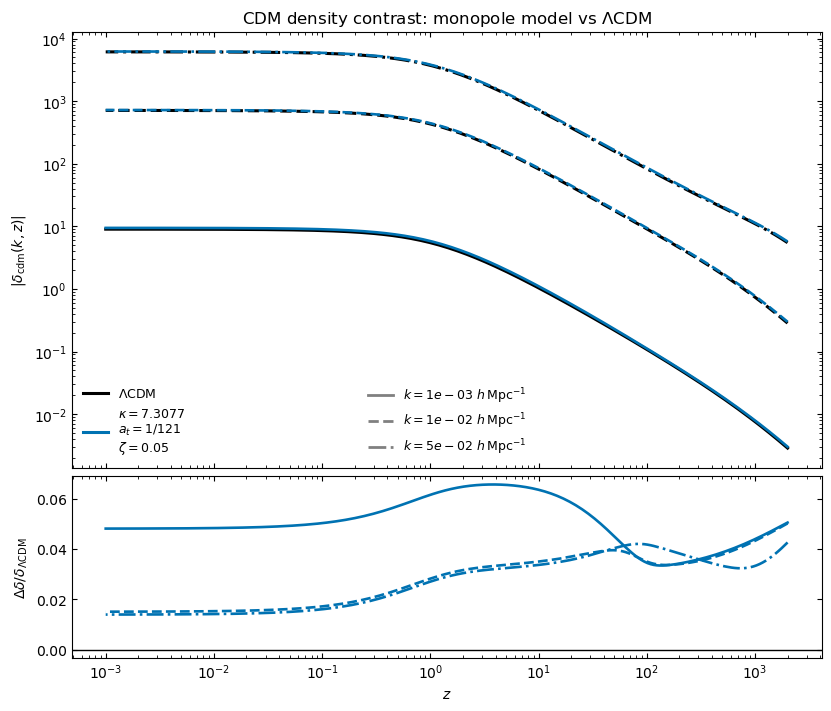

In [ ]:
# ============================================================
# Plot
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8.2, 7.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3.0, 1.25]},
    constrained_layout=True
)

# Color per model
model_colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

# Linestyle per k-mode
k_linestyles = ["-", "--", "-."]

# -------------------------
# Top panel: |delta_cdm|
# -------------------------
# We plot absolute value because density contrasts in synchronous gauge
# may change sign depending on convention/normalization.
for ik, k in enumerate(k_modes):
    y_lcdm = np.abs(lcdm["delta_cdm"][:, ik])

    ax1.plot(
        lcdm["z"], y_lcdm,
        color="black",
        lw=2.2,
        ls=k_linestyles[ik],
    )

for im, model in enumerate(models):
    for ik, k in enumerate(k_modes):
        y = np.abs(model["delta_cdm"][:, ik])

        ax1.plot(
            model["z"], y,
            color=model_colors[im],
            lw=1.9,
            ls=k_linestyles[ik],
        )

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.invert_xaxis()  # high z on left, low z on right

ax1.set_ylabel(r"$|\delta_{\rm cdm}(k,z)|$")
ax1.set_title(r"CDM density contrast: monopole model vs $\Lambda$CDM")

ax1.tick_params(which="both", direction="in", top=True, right=True)

# -------------------------
# Bottom panel: fractional difference
# -------------------------
for im, model in enumerate(models):
    for ik, k in enumerate(k_modes):
        ref = lcdm["delta_cdm"][:, ik]
        val = model["delta_cdm"][:, ik]

        frac = np.full_like(ref, np.nan, dtype=float)
        valid = np.isfinite(ref) & np.isfinite(val) & (np.abs(ref) > 1e-30)
        frac[valid] = (val[valid] - ref[valid]) / ref[valid]

        ax2.plot(
            model["z"], frac,
            color=model_colors[im],
            lw=1.9,
            ls=k_linestyles[ik],
        )

ax2.axhline(0.0, color="black", lw=1.0)

ax2.set_xscale("log")
ax2.invert_xaxis()

ax2.set_xlabel(r"$z$")
ax2.set_ylabel(r"$\Delta\delta/\delta_{\Lambda{\rm CDM}}$")

ax2.tick_params(which="both", direction="in", top=True, right=True)

# -------------------------
# Legends
# -------------------------
legend_models = [
    Line2D([0], [0], color="black", lw=2.2, label=r"$\Lambda$CDM")
]

for im, model in enumerate(models):
    legend_models.append(
        Line2D([0], [0], color=model_colors[im], lw=2.2, label=model["label"])
    )

legend_k = [
    Line2D([0], [0], color="gray", lw=2.0, ls=k_linestyles[i],
           label=fr"$k={k_modes[i]:.0e}\ h\,\mathrm{{Mpc}}^{{-1}}$")
    for i in range(len(k_modes))
]

leg1 = ax1.legend(
    handles=legend_models,
    loc="lower left",
    frameon=False,
    fontsize=9
)

leg2 = ax1.legend(
    handles=legend_k,
    loc="lower center",
    frameon=False,
    fontsize=9
)

ax1.add_artist(leg1)

# ============================================================
# Show / save
# ============================================================

if flag_save_plot:
    plt.savefig(plot_filename, bbox_inches="tight")
    print(f"\nSaved plot to: {plot_filename}")
else:
    plt.show()

In [8]:
# ============================================================
# Helpers
# ============================================================

def build_model(base_params, extra_params=None):
    cosmo = Class()
    pars = dict(base_params)
    if extra_params is not None:
        pars.update(extra_params)
    cosmo.set(pars)
    cosmo.compute()
    return cosmo


def compute_transfer_history(base_params, z_grid, k_modes_hmpc, field_name, extra_params=None):
    """
    Compute one transfer field as a function of z for selected k-modes.

    field_name examples:
        'd_cdm', 'd_b', 'd_m', 'd_tot', 'phi', 'psi', 'd_g', 'd_ur'
    """
    cosmo = build_model(base_params, extra_params)
    arr = np.zeros((len(z_grid), len(k_modes_hmpc)))

    try:
        for iz, z in enumerate(z_grid):
            tr = cosmo.get_transfer(z)

            k_arr = np.asarray(tr['k (h/Mpc)'], dtype=float)
            y_arr = np.asarray(tr[field_name], dtype=float)

            order = np.argsort(k_arr)
            k_sorted = k_arr[order]
            y_sorted = y_arr[order]

            arr[iz, :] = np.interp(
                k_modes_hmpc,
                k_sorted,
                y_sorted,
                left=np.nan,
                right=np.nan
            )
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()

    return {
        "z": np.asarray(z_grid, dtype=float),
        "a": 1.0 / (1.0 + np.asarray(z_grid, dtype=float)),
        "k_modes": np.asarray(k_modes_hmpc, dtype=float),
        "field_name": field_name,
        "values": arr,
    }

def make_transfer_plot(field_name, ylabel_top=None, ylabel_bottom=None, filename=None):
    lcdm = compute_transfer_history(
        base_params=base,
        z_grid=z_samples,
        k_modes_hmpc=k_modes,
        field_name=field_name,
        extra_params=None,
    )

    models = []
    for case in cases:
        res = compute_transfer_history(
            base_params=base,
            z_grid=z_samples,
            k_modes_hmpc=k_modes,
            field_name=field_name,
            extra_params={
                "f_mon": case["f_mon"],
                "a_t_mon": case["a_t_mon"],
                "kappa_mon": case["kappa_mon"],
            },
        )
        res["label"] = case["label"]
        res["params"] = dict(case)
        models.append(res)

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(8.2, 7.0),
        sharex=True,
        gridspec_kw={"height_ratios": [3.0, 1.25]},
        constrained_layout=False
    )

    model_colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]
    k_linestyles = ["-", "--", "-."]

    # top panel
    for ik, k in enumerate(k_modes):
        ax1.plot(
            lcdm["z"],
            np.abs(lcdm["values"][:, ik]),
            color="black",
            lw=2.2,
            ls=k_linestyles[ik],
        )

    for im, model in enumerate(models):
        for ik, k in enumerate(k_modes):
            ax1.plot(
                model["z"],
                np.abs(model["values"][:, ik]),
                color=model_colors[im],
                lw=1.9,
                ls=k_linestyles[ik],
            )

    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_ylabel(ylabel_top if ylabel_top is not None else rf"$|{field_name}(k,z)|$")
    ax1.set_title(rf"Transfer field: {field_name} (monopole model vs $\Lambda$CDM)")
    ax1.tick_params(which="both", direction="in", top=True, right=True)

    # bottom panel
    for im, model in enumerate(models):
        for ik, k in enumerate(k_modes):
            ref = lcdm["values"][:, ik]
            val = model["values"][:, ik]

            frac = np.full_like(ref, np.nan, dtype=float)
            valid = np.isfinite(ref) & np.isfinite(val) & (np.abs(ref) > 1e-30)
            frac[valid] = (val[valid] - ref[valid]) / ref[valid]

            ax2.plot(
                model["z"],
                frac,
                color=model_colors[im],
                lw=1.9,
                ls=k_linestyles[ik],
            )

    ax2.axhline(0.0, color="black", lw=1.0)
    ax2.set_xscale("log")
    ax2.set_xlabel(r"$z$")
    if ylabel_bottom is not None:
        ax2.set_ylabel(ylabel_bottom)
    else:
        ax2.set_ylabel(r"$\Delta$ " + field_name + r" / " + field_name + r"$_{\Lambda{\rm CDM}}$")
    ax2.tick_params(which="both", direction="in", top=True, right=True)

    legend_models = [Line2D([0], [0], color="black", lw=2.2, label=r"$\Lambda$CDM")]
    for im, model in enumerate(models):
        legend_models.append(
            Line2D([0], [0], color=model_colors[im], lw=2.2, label=model["label"])
        )

    legend_k = [
        Line2D(
            [0], [0],
            color="gray",
            lw=2.0,
            ls=k_linestyles[i],
            label=fr"$k={k_modes[i]:.0e}\ h\,\mathrm{{Mpc}}^{{-1}}$"
        )
        for i in range(len(k_modes))
    ]

    # leave room on the right for legends
    fig.subplots_adjust(right=0.77, hspace=0.08)

    # legend for models
    leg1 = ax1.legend(
        handles=legend_models,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        frameon=False,
        fontsize=9,
        borderaxespad=0.0,
    )

    # legend for k-modes
    leg2 = ax1.legend(
        handles=legend_k,
        loc="lower left",
        bbox_to_anchor=(1.02, 0.00),
        frameon=False,
        fontsize=9,
        borderaxespad=0.0,
    )

    ax1.add_artist(leg1)

    if flag_save_plot and filename is not None:
        plt.savefig(filename, bbox_inches="tight")
    else:
        plt.show()


## PLOT TRANSFER PLOT

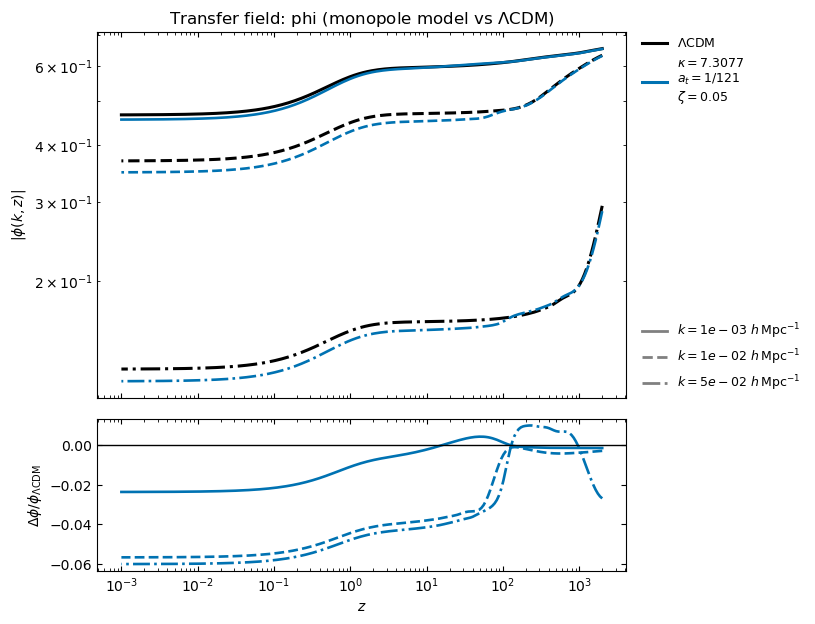

In [ ]:
make_transfer_plot(
    field_name="phi",
    ylabel_top=r"$|\phi(k,z)|$",
    ylabel_bottom=r"$\Delta\phi/\phi_{\Lambda{\rm CDM}}$",
    filename="phi_monopole_vs_lcdm.pdf",
)

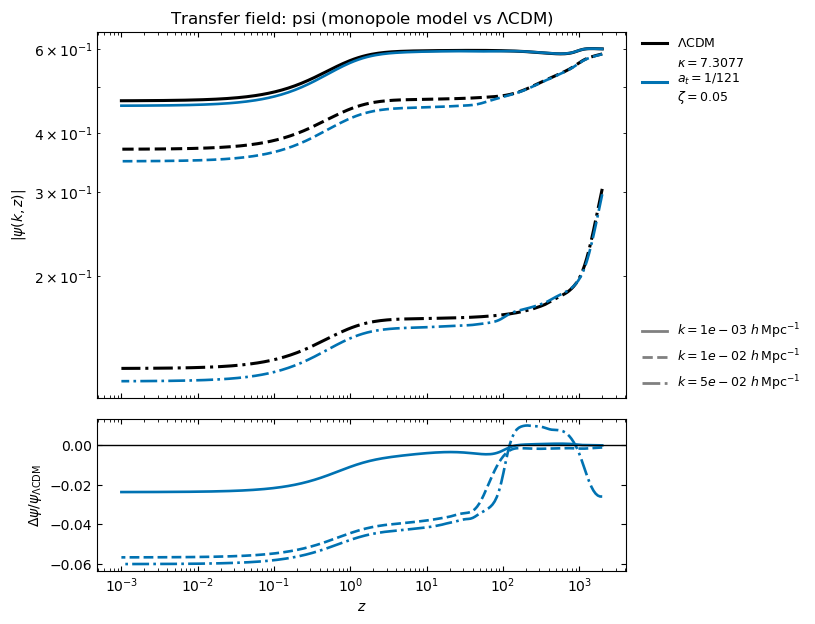

In [ ]:
make_transfer_plot(
    field_name="psi",
    ylabel_top=r"$|\psi(k,z)|$",
    ylabel_bottom=r"$\Delta\psi/\psi_{\Lambda{\rm CDM}}$",
    filename="psi_monopole_vs_lcdm.pdf",
)

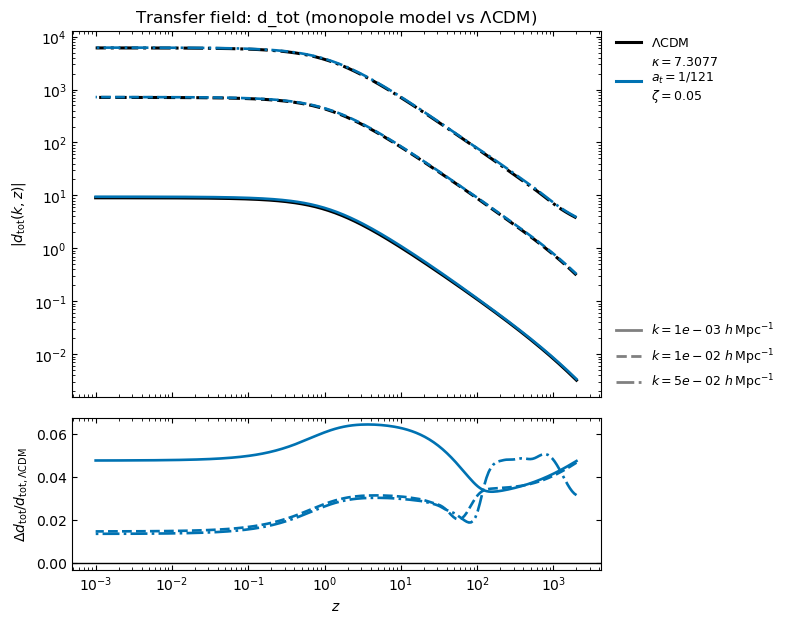

In [ ]:
make_transfer_plot(
    field_name="d_tot",
    ylabel_top=r"$|d_{\rm tot}(k,z)|$",
    ylabel_bottom=r"$\Delta d_{\rm tot}/d_{{\rm tot},\Lambda{\rm CDM}}$",
    filename="dtot_monopole_vs_lcdm.pdf",
)

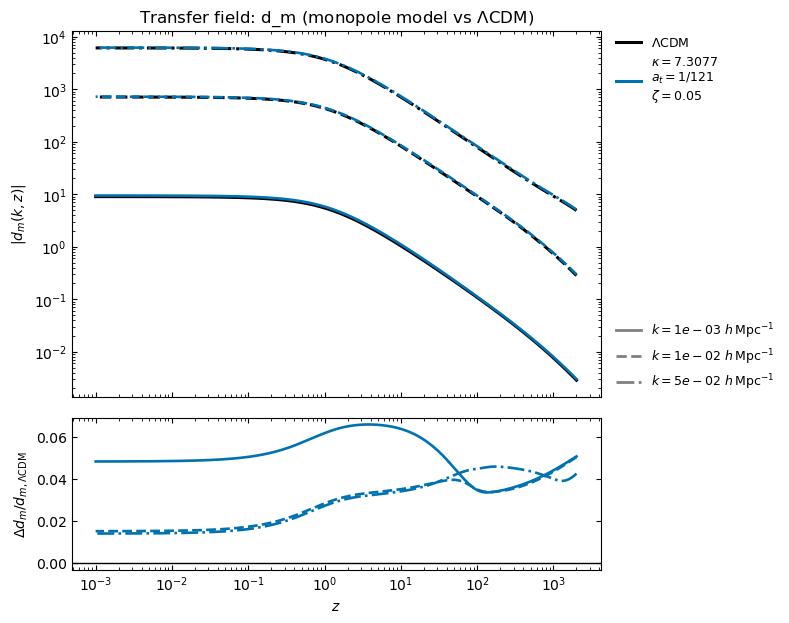

In [ ]:
make_transfer_plot(
    field_name="d_m",
    ylabel_top=r"$|d_m(k,z)|$",
    ylabel_bottom=r"$\Delta d_m/d_{m,\Lambda{\rm CDM}}$",
    filename="dm_monopole_vs_lcdm.pdf",
)

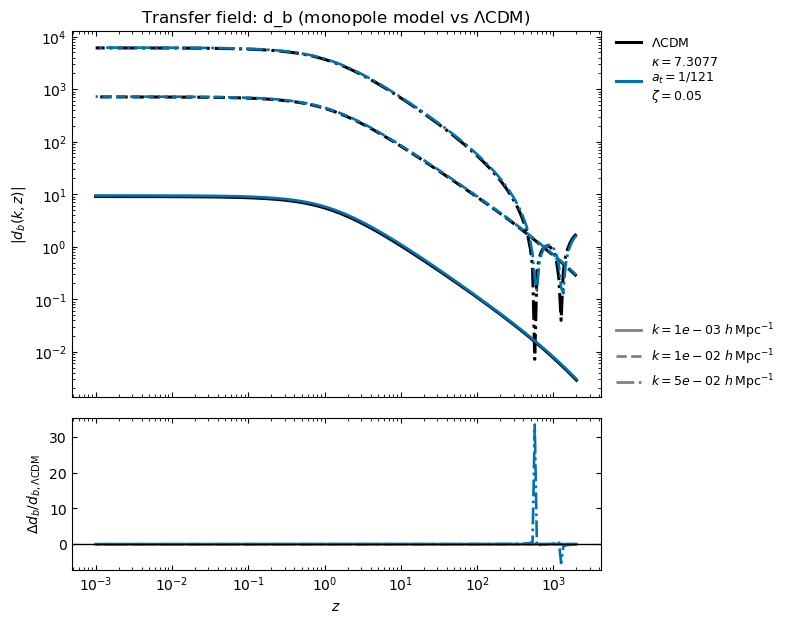

In [ ]:
make_transfer_plot(
    field_name="d_b",
    ylabel_top=r"$|d_b(k,z)|$",
    ylabel_bottom=r"$\Delta d_b/d_{b,\Lambda{\rm CDM}}$",
    filename="db_monopole_vs_lcdm.pdf",
)

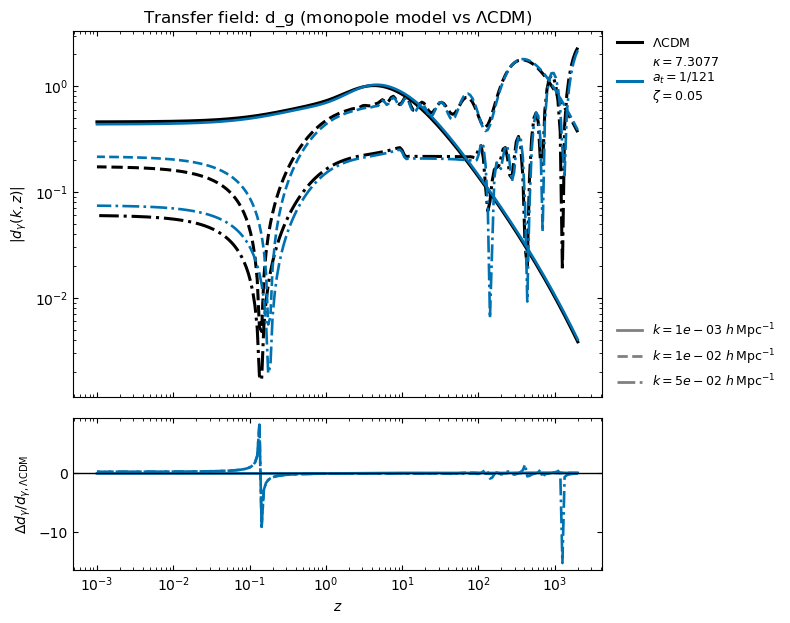

In [ ]:
make_transfer_plot(
    field_name="d_g",
    ylabel_top=r"$|d_\gamma(k,z)|$",
    ylabel_bottom=r"$\Delta d_\gamma/d_{\gamma,\Lambda{\rm CDM}}$",
    filename="dg_monopole_vs_lcdm.pdf",
)

## PLOT RAW TRANSFER PLOT

In [9]:
def make_raw_transfer_plot(
    field_name,
    k_plot,
    sign=1.0,
    ylabel_top=None,
    ylabel_bottom=None,
    ratio_mode="model_over_lcdm",   # "model_over_lcdm" or "frac_diff"
    filename=None,
    show_at=True,
):
    """
    Plot 'raw' transfer field for one chosen k-mode.

    Parameters
    ----------
    field_name : str
        e.g. "d_cdm", "d_tot", "d_g", "d_ur", "phi", "psi"
    k_plot : float
        k in h/Mpc
    sign : float
        +1 or -1. Useful if you want to plot e.g. -d_cdm or -phi
    ylabel_top : str or None
        Custom y-label for top panel
    ylabel_bottom : str or None
        Custom y-label for bottom panel
    ratio_mode : str
        "model_over_lcdm"  -> bottom panel = model / LCDM
        "frac_diff"        -> bottom panel = (model - LCDM)/LCDM
    filename : str or None
        output filename if saving
    show_at : bool
        whether to draw vertical lines at a_t of models
    """

    k_arr = np.array([k_plot], dtype=float)

    # LCDM
    lcdm = compute_transfer_history(
        base_params=base,
        z_grid=z_samples,
        k_modes_hmpc=k_arr,
        field_name=field_name,
        extra_params=None,
    )

    # models
    models = []
    for case in cases:
        res = compute_transfer_history(
            base_params=base,
            z_grid=z_samples,
            k_modes_hmpc=k_arr,
            field_name=field_name,
            extra_params={
                "f_mon": case["f_mon"],
                "a_t_mon": case["a_t_mon"],
                "kappa_mon": case["kappa_mon"],
            },
        )
        res["label"] = case["label"]
        res["params"] = dict(case)
        models.append(res)

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(8.0, 6.8),
        sharex=True,
        gridspec_kw={"height_ratios": [3.0, 1.25]},
        constrained_layout=False,
    )

    # slightly more room for legend on the right
    fig.subplots_adjust(right=0.77, hspace=0.08)

    model_colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

    # sort by scale factor
    a_ref = lcdm["a"]
    order_ref = np.argsort(a_ref)
    a_ref = a_ref[order_ref]
    y_ref = sign * lcdm["values"][order_ref, 0]

    # Decide if top panel can be log-scale
    all_top_series = [y_ref.copy()]

    for model in models:
        a_model = model["a"]
        order_model = np.argsort(a_model)
        y_model = sign * model["values"][order_model, 0]
        all_top_series.append(y_model.copy())

    # --------------------------
    # Top panel
    # --------------------------
    ax1.plot(a_ref, y_ref, color="black", lw=2.3, label=r"$\Lambda$CDM")

    for im, model in enumerate(models):
        a_model = model["a"]
        order_model = np.argsort(a_model)
        a_model = a_model[order_model]
        y_model = sign * model["values"][order_model, 0]

        ax1.plot(
            a_model, y_model,
            color=model_colors[im],
            lw=2.0,
            label=model["label"],
        )

        if show_at:
            a_t = model["params"]["a_t_mon"]
            ax1.axvline(a_t, color=model_colors[im], lw=1.1, ls=":", alpha=0.85)
            ax2.axvline(a_t, color=model_colors[im], lw=1.1, ls=":", alpha=0.85)

    ax1.set_xscale("log")

    # If all plotted values are positive -> log scale. Otherwise symlog.
    concatenated = np.concatenate([arr[np.isfinite(arr)] for arr in all_top_series])
    if np.all(concatenated > 0):
        ax1.set_yscale("log")
    else:
        # fallback if sign/field leads to sign changes
        ax1.set_yscale("symlog", linthresh=1e-4)

    if ylabel_top is not None:
        ax1.set_ylabel(ylabel_top)
    else:
        prefix = "-" if sign < 0 else ""
        ax1.set_ylabel(r"$" + prefix + field_name + r"(k,a)$")

    ax1.set_title(rf"Transfer field: {field_name},  $k={k_plot:.0e}\ h\,\mathrm{{Mpc}}^{{-1}}$")
    ax1.tick_params(which="both", direction="in", top=True, right=True)

    # --------------------------
    # Bottom panel
    # --------------------------
    if ratio_mode == "model_over_lcdm":
        ax2.axhline(1.0, color="black", lw=1.0)
    elif ratio_mode == "frac_diff":
        ax2.axhline(0.0, color="black", lw=1.0)
    else:
        raise ValueError("ratio_mode must be 'model_over_lcdm' or 'frac_diff'")

    for im, model in enumerate(models):
        a_model = model["a"]
        order_model = np.argsort(a_model)
        a_model = a_model[order_model]
        y_model = sign * model["values"][order_model, 0]

        # Interpolate LCDM onto the same a-grid if needed
        y_ref_interp = np.interp(a_model, a_ref, y_ref, left=np.nan, right=np.nan)

        valid = np.isfinite(y_model) & np.isfinite(y_ref_interp) & (np.abs(y_ref_interp) > 1e-30)

        ratio = np.full_like(y_model, np.nan, dtype=float)

        if ratio_mode == "model_over_lcdm":
            ratio[valid] = y_model[valid] / y_ref_interp[valid]
        else:
            ratio[valid] = (y_model[valid] - y_ref_interp[valid]) / y_ref_interp[valid]

        ax2.plot(
            a_model, ratio,
            color=model_colors[im],
            lw=2.0,
        )

    ax2.set_xscale("log")
    ax2.set_xlabel(r"$a$")

    if ylabel_bottom is not None:
        ax2.set_ylabel(ylabel_bottom)
    else:
        if ratio_mode == "model_over_lcdm":
            ax2.set_ylabel(r"$" + field_name + r"/" + field_name + r"_{\Lambda{\rm CDM}}$")
        else:
            ax2.set_ylabel(r"$\Delta " + field_name + r"/" + field_name + r"_{\Lambda{\rm CDM}}$")

    ax2.tick_params(which="both", direction="in", top=True, right=True)

    # legend on the right
    legend_models = [Line2D([0], [0], color="black", lw=2.3, label=r"$\Lambda$CDM")]
    for im, model in enumerate(models):
        legend_models.append(
            Line2D([0], [0], color=model_colors[im], lw=2.0, label=model["label"])
        )

    ax1.legend(
        handles=legend_models,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
        fontsize=10,
        borderaxespad=0.0,
    )

    if flag_save_plot and filename is not None:
        plt.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

In [10]:
flag_save_plot = False

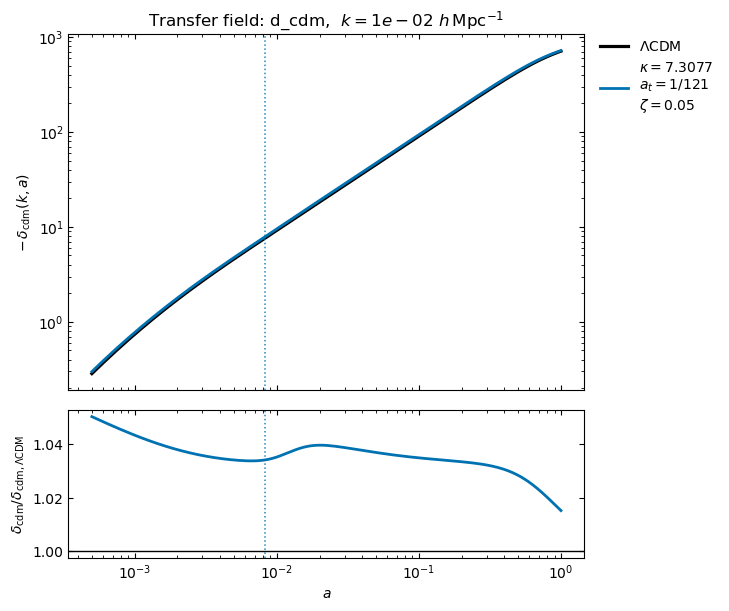

In [11]:
make_raw_transfer_plot(
    field_name="d_cdm",
    k_plot=1e-2,
    sign=-1.0,
    ylabel_top=r"$-\,\delta_{\rm cdm}(k,a)$",
    ylabel_bottom=r"$\delta_{\rm cdm}/\delta_{{\rm cdm},\Lambda{\rm CDM}}$",
    ratio_mode="model_over_lcdm",
    filename="raw_dcdm_k1e-2.pdf",
)

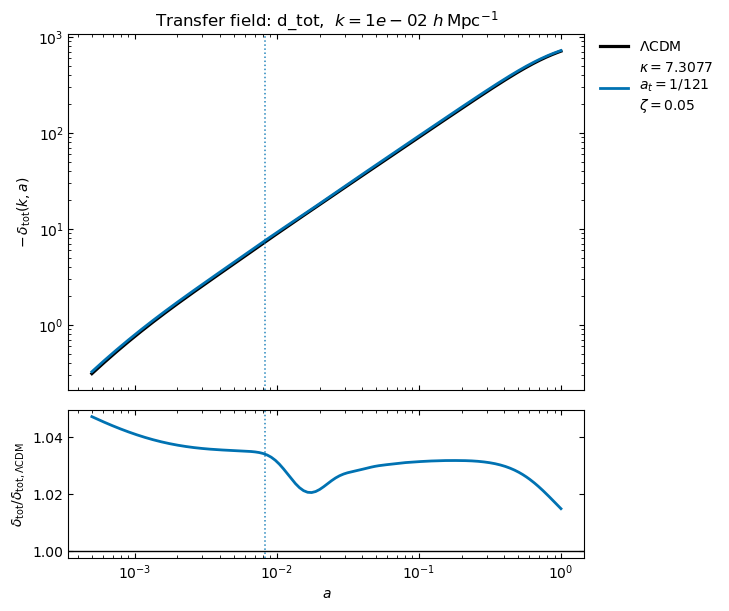

In [13]:
make_raw_transfer_plot(
    field_name="d_tot",
    k_plot=1e-2,
    sign=-1.0,
    ylabel_top=r"$-\,\delta_{\rm tot}(k,a)$",
    ylabel_bottom=r"$\delta_{\rm tot}/\delta_{{\rm tot},\Lambda{\rm CDM}}$",
    ratio_mode="model_over_lcdm",
    filename="raw_dtot_k1e-2.pdf",
)

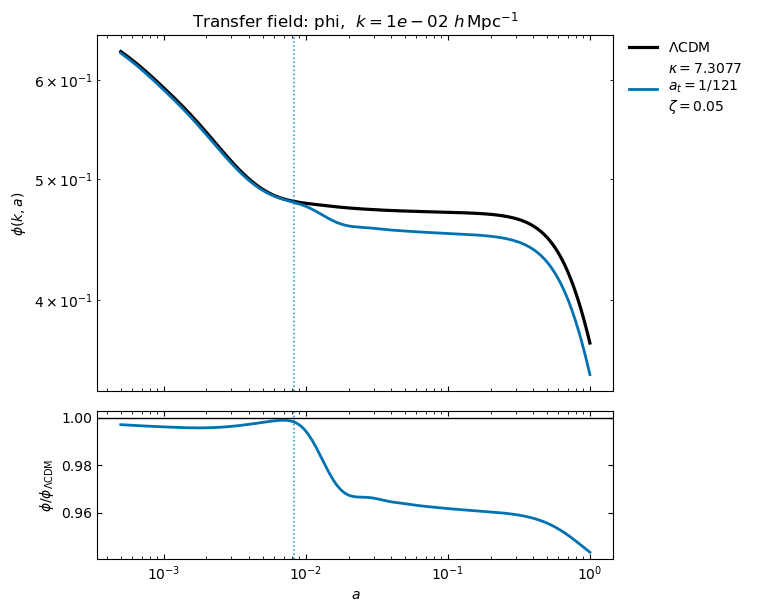

In [14]:
make_raw_transfer_plot(
    field_name="phi",
    k_plot=1e-2,
    sign=1.0,
    ylabel_top=r"$\phi(k,a)$",
    ylabel_bottom=r"$\phi/\phi_{\Lambda{\rm CDM}}$",
    ratio_mode="model_over_lcdm",
    filename="raw_phi_k1e-2.pdf",
)

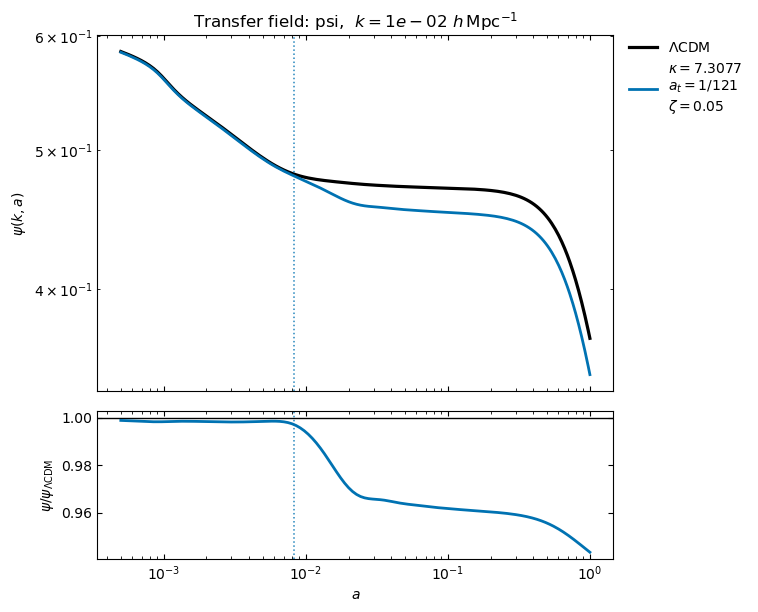

In [15]:
make_raw_transfer_plot(
    field_name="psi",
    k_plot=1e-2,
    sign=1.0,
    ylabel_top=r"$\psi(k,a)$",
    ylabel_bottom=r"$\psi/\psi_{\Lambda{\rm CDM}}$",
    ratio_mode="model_over_lcdm",
    filename="raw_psi_k1e-2.pdf",
)

## DARK RADIATION CONTRAST

In [16]:
def print_monopole_transfer_keys(z_test=10.0):
    cosmo = Class()

    pars = dict(base)
    pars.update({
        "f_mon": cases[0]["f_mon"],
        "a_t_mon": cases[0]["a_t_mon"],
        "kappa_mon": cases[0]["kappa_mon"],
    })

    cosmo.set(pars)
    cosmo.compute()

    tr = cosmo.get_transfer(z_test)

    print(f"Available transfer keys at z={z_test}:")
    for key in tr.keys():
        print("   ", repr(key))

    cosmo.struct_cleanup()
    cosmo.empty()

In [17]:
print_monopole_transfer_keys(z_test=10.0)

Available transfer keys at z=10.0:
    'k (h/Mpc)'
    'd_g'
    'd_b'
    'd_cdm'
    'd_ur'
    'd_mon'
    'd_dr'
    'd_m'
    'd_tot'
    'phi'
    'psi'


In [18]:
def make_monopole_only_plot_single(
    field_name,
    k_plot,
    sign=1.0,
    ylabel_top=None,
    filename=None,
    show_at=True,
    yscale_mode="auto",   # "auto", "linear", "log", "symlog"
):
    """
    Plot a transfer field that exists only in the monopole model,
    e.g. 'd_mon' or 'd_dr', using only a single upper panel.

    Parameters
    ----------
    field_name : str
        e.g. "d_dr" or "d_mon"
    k_plot : float
        chosen k in h/Mpc
    sign : float
        +1 or -1, useful if you want to plot -d_dr or -d_mon
    ylabel_top : str or None
        custom y-label
    filename : str or None
        output filename if saving
    show_at : bool
        whether to show vertical lines at a_t
    yscale_mode : str
        "auto"   -> choose log if all values > 0, otherwise symlog
        "linear" -> force linear y-axis
        "log"    -> force log y-axis
        "symlog" -> force symlog y-axis
    """

    k_arr = np.array([k_plot], dtype=float)

    # --------------------------------------------------
    # Compute all monopole models
    # --------------------------------------------------
    models = []
    for case in cases:
        res = compute_transfer_history(
            base_params=base,
            z_grid=z_samples,
            k_modes_hmpc=k_arr,
            field_name=field_name,
            extra_params={
                "f_mon": case["f_mon"],
                "a_t_mon": case["a_t_mon"],
                "kappa_mon": case["kappa_mon"],
            },
        )
        res["label"] = case["label"]
        res["params"] = dict(case)
        models.append(res)

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------
    fig, ax1 = plt.subplots(
        1, 1,
        figsize=(8.0, 5.4),
        constrained_layout=False,
    )

    fig.subplots_adjust(right=0.77)

    model_colors = ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"]

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    all_top_series = []

    for im, model in enumerate(models):
        a_model = model["a"]
        order_model = np.argsort(a_model)
        a_model = a_model[order_model]
        y_model = sign * model["values"][order_model, 0]

        finite_vals = y_model[np.isfinite(y_model)]
        if len(finite_vals) > 0:
            all_top_series.append(finite_vals)

        ax1.plot(
            a_model,
            y_model,
            color=model_colors[im % len(model_colors)],
            lw=2.0,
            label=model["label"],
        )

        if show_at:
            a_t = model["params"]["a_t_mon"]
            ax1.axvline(
                a_t,
                color=model_colors[im % len(model_colors)],
                lw=1.0,
                ls=":",
                alpha=0.85,
            )

    ax1.set_xscale("log")

    # --------------------------------------------------
    # Y scale choice
    # --------------------------------------------------
    if yscale_mode == "linear":
        ax1.set_yscale("linear")

    elif yscale_mode == "log":
        ax1.set_yscale("log")

    elif yscale_mode == "symlog":
        ax1.set_yscale("symlog", linthresh=1e-6)

    elif yscale_mode == "auto":
        if len(all_top_series) > 0:
            concat = np.concatenate(all_top_series)
            if np.all(concat > 0):
                ax1.set_yscale("log")
            else:
                ax1.set_yscale("symlog", linthresh=1e-6)
        else:
            ax1.set_yscale("linear")

    else:
        raise ValueError("yscale_mode must be 'auto', 'linear', 'log', or 'symlog'")

    # --------------------------------------------------
    # Labels
    # --------------------------------------------------
    if ylabel_top is not None:
        ax1.set_ylabel(ylabel_top)
    else:
        prefix = "-" if sign < 0 else ""
        ax1.set_ylabel(r"$" + prefix + field_name + r"(k,a)$")

    ax1.set_xlabel(r"$a$")
    ax1.set_title(field_name + rf" for monopole models,  $k={k_plot:.0e}\ h\,\mathrm{{Mpc}}^{{-1}}$")
    ax1.tick_params(which="both", direction="in", top=True, right=True)

    # --------------------------------------------------
    # Legend
    # --------------------------------------------------
    legend_models = []
    for im, model in enumerate(models):
        legend_models.append(
            Line2D(
                [0], [0],
                color=model_colors[im % len(model_colors)],
                lw=2.0,
                label=model["label"]
            )
        )

    ax1.legend(
        handles=legend_models,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
        fontsize=9,
        borderaxespad=0.0,
    )

    if flag_save_plot and filename is not None:
        plt.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

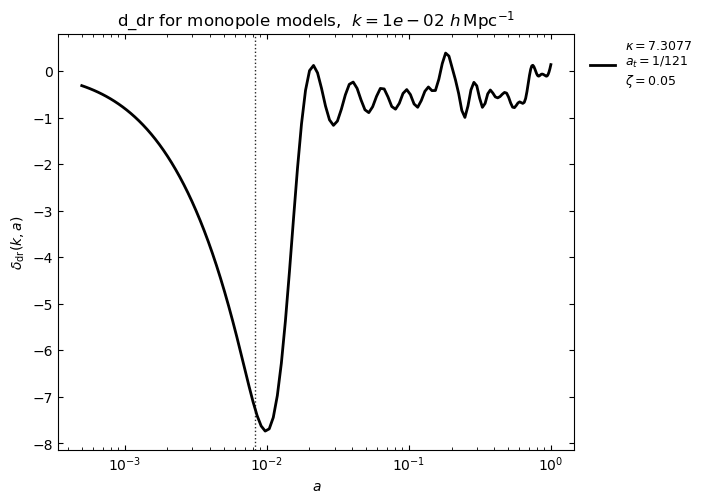

In [19]:
make_monopole_only_plot_single(
    field_name="d_dr",
    k_plot=1e-2,
    sign=1.0,
    ylabel_top=r"$\delta_{\rm dr}(k,a)$",
    yscale_mode="linear",
    filename="d_dr_single_panel.pdf",
)

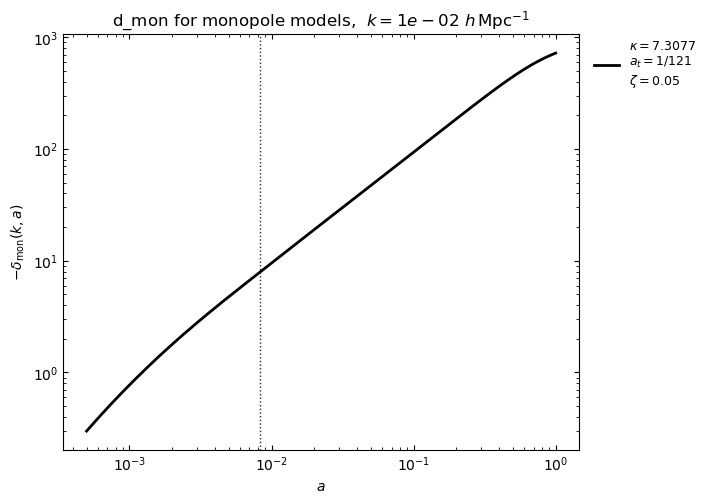

In [20]:
make_monopole_only_plot_single(
    field_name="d_mon",
    k_plot=1e-2,
    sign=-1.0,
    ylabel_top=r"$-\delta_{\rm mon}(k,a)$",
    yscale_mode="auto",
    filename="d_mon_single_panel.pdf",
)